# Triagem Médica (Avaliação de Gravidade/Prioridade)

**Aluno:** Henrique de Andrade França  
**Matrícula:** 20210024961

Instalação e Preparação do Ambiente

In [ ]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 3.4 MB/s eta 0:00:00


Definição das Variáveis Linguísticas e Conjuntos Fuzzy

In [ ]:
# 1. variaveis de entrada (antecedentes)

# temperatura do paciente: de 35.0 a 42.0 ºC (passo de 0.1 para maior precisao)
temp = ctrl.Antecedent(np.arange(35.0, 42.1, 0.1), 'temperatura')

# saturacao de oxigenio (O2): de 80 a 100 %
sat = ctrl.Antecedent(np.arange(80, 100.1, 0.1), 'saturacao')

# 2. variavel de saida (consequente)
# score de prioridade de atendimento: de 0 a 100
prio = ctrl.Consequent(np.arange(0, 101, 1), 'prioridade')


# 3. funcoes de pertinencia

# TEMPERATURA (°C)
# normal: ate 37.5 eh considerado predominantemente normal
temp['normal'] = fuzz.trapmf(temp.universe, [35.0, 35.0, 36.8, 37.5])
# febril: pico em 37.8 (exatamente o limiar classico), caindo ate 38.5
temp['febril'] = fuzz.trimf(temp.universe, [37.0, 37.8, 38.5])
# alta: de 38.0 em diante, consolidando como febre alta
temp['alta']   = fuzz.trapmf(temp.universe, [38.0, 39.5, 42.0, 42.0])

# SATURACAO DE O2 (%)
# critica: abaixo de 92% a situacao exige atencao medica grave
sat['critica'] = fuzz.trapmf(sat.universe, [80, 80, 88, 92])
# alerta: entre 90% e 95%
sat['alerta']  = fuzz.trimf(sat.universe, [90, 93, 95])
# normal: 94% a 100%
sat['normal']  = fuzz.trapmf(sat.universe, [94, 98, 100, 100])

# PRIORIDADE (0 a 100 - score de risco)
# verde (atendimento padrao)
prio['verde']    = fuzz.trimf(prio.universe, [0, 0, 45])
# amarela (urgente)
prio['amarela']  = fuzz.trimf(prio.universe, [30, 50, 70])
# vermelha (emergencia imediata)
prio['vermelha'] = fuzz.trimf(prio.universe, [55, 100, 100])

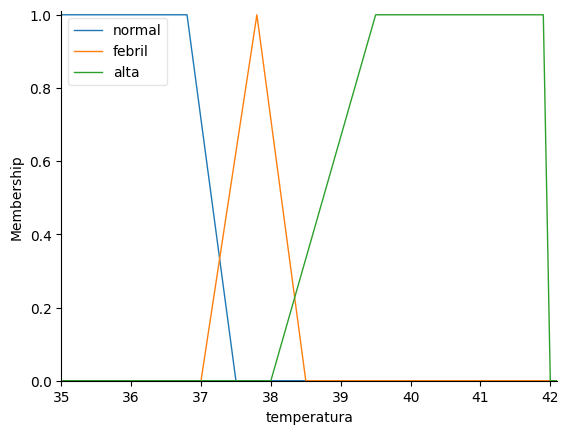

In [ ]:
temp.view()

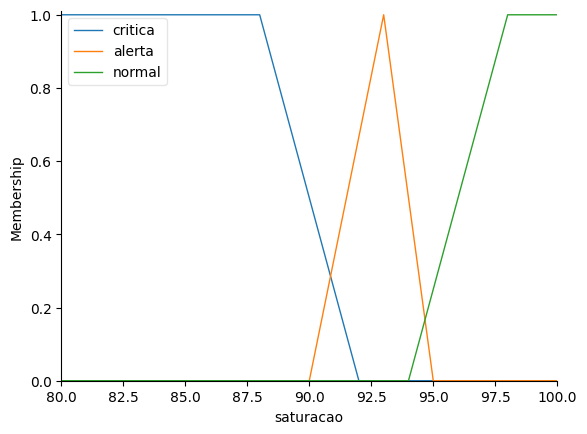

In [ ]:
sat.view()

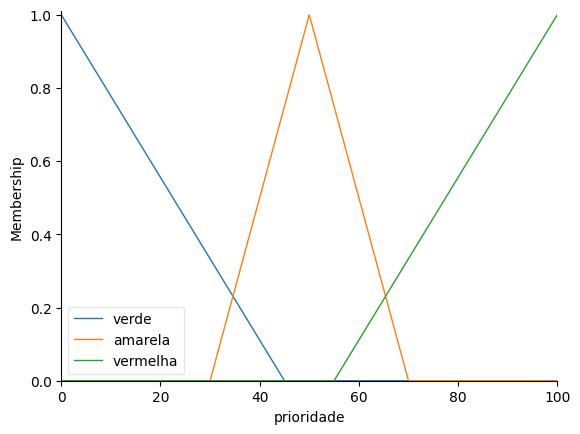

In [ ]:
prio.view()

Base de Regras Fuzzy

In [ ]:
# --- SUBMATRIZ 1: PACIENTE SEM FEBRE (temperatura normal) ---
# R1: temperatura normal + saturacao normal = caso ambulatorial simples
r1 = ctrl.Rule(temp['normal'] & sat['normal'], prio['verde'])
# R2: temperatura normal + saturacao em alerta = necessita investigacao, quadro instavel
r2 = ctrl.Rule(temp['normal'] & sat['alerta'], prio['amarela'])
# R3: temperatura normal + saturacao critica = hipoxia grave isolada (ex: asma aguda, engasgo)
r3 = ctrl.Rule(temp['normal'] & sat['critica'], prio['vermelha'])

# --- SUBMATRIZ 2: PACIENTE FEBRIL LEVE (temperatura febril) ---
# R4: estado febril + saturacao normal = sintoma leve (ex: virose comum). pode aguardar
r4 = ctrl.Rule(temp['febril'] & sat['normal'], prio['verde'])
# R5: estado febril + saturacao em alerta = risco moderado de evolucao para desconforto respiratorio
r5 = ctrl.Rule(temp['febril'] & sat['alerta'], prio['amarela'])
# R6: estado febril + saturacao critica = emergencia medica por comprometimento respiratorio evidente
r6 = ctrl.Rule(temp['febril'] & sat['critica'], prio['vermelha'])

# --- SUBMATRIZ 3: PACIENTE COM FEBRE ALTA (temperatura alta) ---
# R7: febre alta + saturacao normal = exige medicacao urgente (risco de convulsao), mas respiracao estavel
r7 = ctrl.Rule(temp['alta'] & sat['normal'], prio['amarela'])
# R8: febre alta + saturacao em alerta = quadro infeccioso sistemico avancado afetando os pulmoes
r8 = ctrl.Rule(temp['alta'] & sat['alerta'], prio['vermelha'])
# R9: febre alta + saturacao critica = estado gravissimo (ex: pneumonia severa / choque septico iminente)
r9 = ctrl.Rule(temp['alta'] & sat['critica'], prio['vermelha'])

# construcao do sistema de controle
sistema_triagem = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7, r8, r9])
simulador = ctrl.ControlSystemSimulation(sistema_triagem)

Execução, Casos de Teste e Análise de Ativação

In [ ]:
def executar_triagem(nome, valor_temp, valor_sat):
    print(f"PACIENTE: {nome}")
    print(f"Sintomas -> Temperatura: {valor_temp}°C | Saturação: {valor_sat}%")
    print("-" * 50)

    # 1. alimentar as entradas (fuzzificacao)
    simulador.input['temperatura'] = valor_temp
    simulador.input['saturacao'] = valor_sat

    # 2. executar a inferencia (mamdani)
    simulador.compute()

    # 3. resultado final (defuzzificacao pelo centroide)
    resultado = simulador.output['prioridade']
    print(f"SCORE DE PRIORIDADE GERADO: {resultado:.2f} / 100")

    # 4. analise: quais regras foram ativadas e influenciaram o resultado
    print("\n[Análise de Ativação das Regras]:")
    for i, rule in enumerate(sistema_triagem.rules):
        activation = rule.aggregate_firing[simulador]
        if activation > 0:
            print(f"Regra {i+1} ativada com força: {activation:.4f} -> {rule.consequent}")
        else:
            print(f"Regra {i+1} ignorada (força 0.0000)")

    # gerar grafico da saida para este caso
    prio.view(sim=simulador)
    plt.show()

PACIENTE: João (Rotina)
Sintomas -> Temperatura: 36.8°C | Saturação: 99%
--------------------------------------------------
SCORE DE PRIORIDADE GERADO: 15.00 / 100

[Análise de Ativação das Regras]:
Regra 1 ativada com força: 1.0000 -> [prioridade[verde]]
Regra 2 ignorada (força 0.0000)
Regra 3 ignorada (força 0.0000)
Regra 4 ignorada (força 0.0000)
Regra 5 ignorada (força 0.0000)
Regra 6 ignorada (força 0.0000)
Regra 7 ignorada (força 0.0000)
Regra 8 ignorada (força 0.0000)
Regra 9 ignorada (força 0.0000)


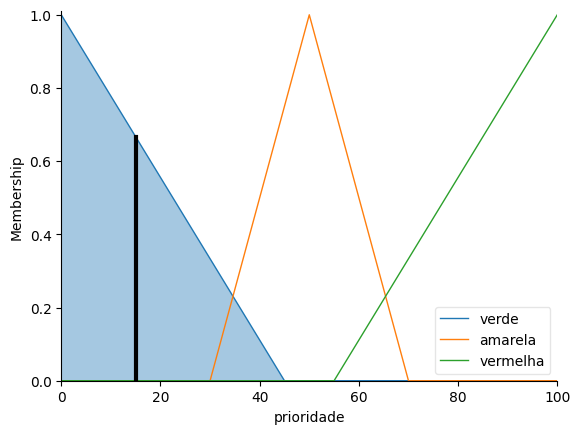

In [ ]:
# TESTE 1: paciente saudavel (rotina)
# temperatura 36.8 (normal) e saturacao 99% (normal)
# esperado: score muito baixo (verde)
executar_triagem("João (Rotina)", 36.8, 99)

PACIENTE: Maria (Atenção)
Sintomas -> Temperatura: 37.2°C | Saturação: 94.2%
--------------------------------------------------
SCORE DE PRIORIDADE GERADO: 46.30 / 100

[Análise de Ativação das Regras]:
Regra 1 ativada com força: 0.0500 -> [prioridade[verde]]
Regra 2 ativada com força: 0.4000 -> [prioridade[amarela]]
Regra 3 ignorada (força 0.0000)
Regra 4 ativada com força: 0.0500 -> [prioridade[verde]]
Regra 5 ativada com força: 0.2500 -> [prioridade[amarela]]
Regra 6 ignorada (força 0.0000)
Regra 7 ignorada (força 0.0000)
Regra 8 ignorada (força 0.0000)
Regra 9 ignorada (força 0.0000)


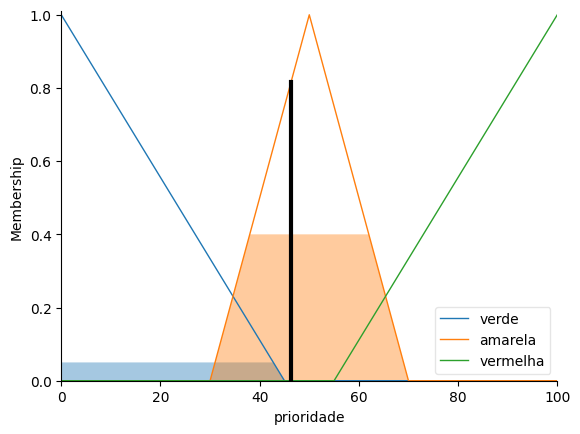

In [ ]:
# TESTE 2: paciente no limiar (imprecisao)
# temperatura 37.2 (entre normal e febril) e saturacao 94% (entre alerta e normal)
# esperado: ativacao fracionada de multiplas regras, score intermediario
executar_triagem("Maria (Atenção)", 37.2, 94.2)

PACIENTE: Carlos (Emergência)
Sintomas -> Temperatura: 39.0°C | Saturação: 85%
--------------------------------------------------
SCORE DE PRIORIDADE GERADO: 83.75 / 100

[Análise de Ativação das Regras]:
Regra 1 ignorada (força 0.0000)
Regra 2 ignorada (força 0.0000)
Regra 3 ignorada (força 0.0000)
Regra 4 ignorada (força 0.0000)
Regra 5 ignorada (força 0.0000)
Regra 6 ignorada (força 0.0000)
Regra 7 ignorada (força 0.0000)
Regra 8 ignorada (força 0.0000)
Regra 9 ativada com força: 0.6667 -> [prioridade[vermelha]]


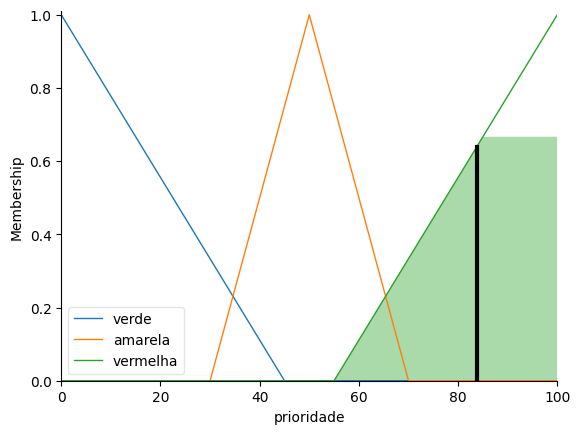

In [ ]:
# TESTE 3: paciente critico
# temperatura 39.0 (alta) e saturacao 85% (critica)
# esperado: score muito alto (vermelho), dominado pela regra 1
executar_triagem("Carlos (Emergência)", 39.0, 85)